In [1]:
# ============================================================
# 05_clustering.ipynb
# Clustering Analysis
# Breast Tumor Classification Project
# ============================================================

In [2]:
# ============================================================
# 1. Import Libraries
# ============================================================

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

# Add project root to Python path
sys.path.append(str(Path().resolve().parent))

In [3]:
# ============================================================
# 2. Import Custom Modules
# ============================================================

from src.config import PROCESSED_DATA_FILE

from src.clustering import (
    scale_features,
    perform_kmeans,
    perform_pca
)

In [4]:
# ============================================================
# 3. Load Dataset
# ============================================================

df = pd.read_csv(
    PROCESSED_DATA_FILE
)

df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [5]:
# ============================================================
# 4. Split Features and Target
# ============================================================

X = df.drop(columns=['Diagnosis'])

y = df['Diagnosis']


In [6]:
# ============================================================
# 5. Feature Scaling
# ============================================================

X_scaled = scale_features(X)

print("Feature scaling completed.")

Feature scaling completed.


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

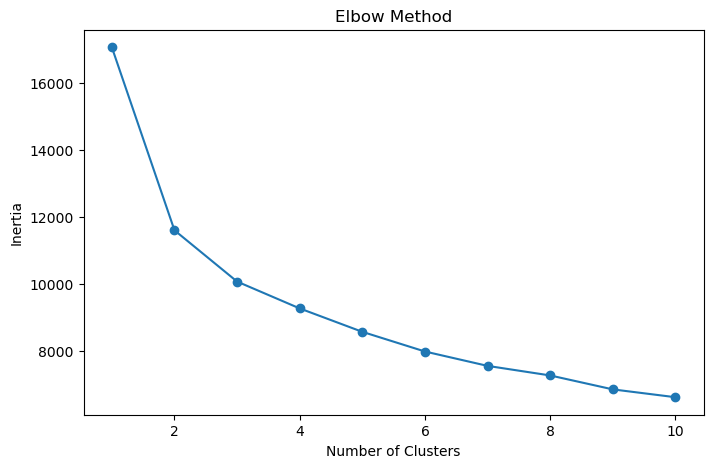

In [7]:
# ============================================================
# 6. Elbow Method
# ============================================================

inertia_values = []

cluster_range = range(1, 11)

for k in cluster_range:

    kmeans_model, _ = perform_kmeans(
        X_scaled,
        n_clusters=k
    )

    inertia_values.append(
        kmeans_model.inertia_
    )

# Plot elbow curve
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_range,
    inertia_values,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [8]:
# ============================================================
# 7. Final KMeans Clustering
# ============================================================

kmeans_model, clusters = perform_kmeans(
    X_scaled,
    n_clusters=2
)

# Add cluster labels
df['cluster'] = clusters

print(df['cluster'].value_counts())

cluster
0    375
1    194
Name: count, dtype: int64


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [9]:
# ============================================================
# 8. PCA for Visualization
# ============================================================

pca_model, X_pca = perform_pca(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame({
    'PCA_1': X_pca[:, 0],
    'PCA_2': X_pca[:, 1],
    'cluster': clusters,
    'diagnosis': y
})

pca_df.head()

,PCA_1,PCA_2,cluster,diagnosis
0,9.192837,1.948583,1,1
1,2.387802,-3.768172,1,1
2,5.733896,-1.075174,1,1
3,7.122953,10.275589,1,1
4,3.935302,-1.948072,1,1


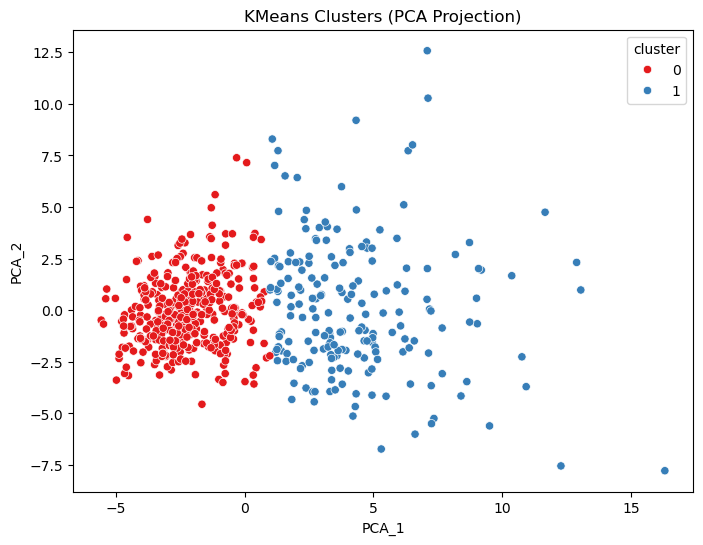

In [10]:
# ============================================================
# 9. Plot KMeans Clusters
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PCA_1',
    y='PCA_2',
    hue='cluster',
    palette='Set1'
)

plt.title("KMeans Clusters (PCA Projection)")

plt.show()

In [11]:
# ============================================================
# 10. Compare Clusters vs Diagnosis
# ============================================================

cluster_comparison = pd.crosstab(
    pca_df['cluster'],
    pca_df['diagnosis']
)

cluster_comparison

diagnosis,0,1
cluster,,
0,339,36
1,18,176


In [12]:
# ============================================================
# 11. Hierarchical Clustering
# ============================================================

linked = linkage(
    X_scaled,
    method='ward'
)


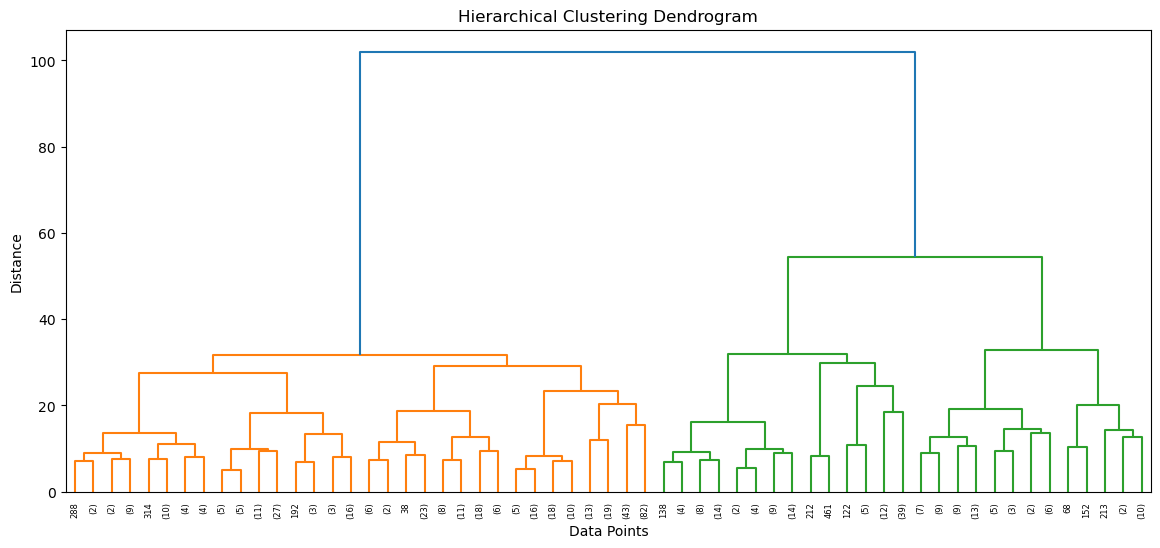

In [13]:
# ============================================================
# 12. Plot Dendrogram
# ============================================================

plt.figure(figsize=(14, 6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.show()

In [14]:
# ============================================================
# 13. Cluster Profiling
# ============================================================

cluster_profile = (
    df
    .groupby('cluster')
    .mean()
)

cluster_profile.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,Diagnosis
cluster,,,,,,,,,,,,,,,,,,,,,
0,12.426691,18.262427,79.820053,486.772267,0.091990,0.076585,0.042679,0.026155,0.172696,0.061746,...,24.132933,89.389920,596.520267,0.125158,0.176886,0.160288,0.076508,0.271324,0.077869,0.096000
1,17.414536,21.275258,115.452887,979.857216,0.104808,0.157993,0.177949,0.092921,0.197526,0.064831,...,28.662320,141.806237,1429.673711,0.146306,0.403839,0.488490,0.188249,0.326322,0.095691,0.907216


# Clustering Summary

## Objective

The purpose of clustering analysis was to explore whether tumor observations naturally form meaningful groups based on their feature characteristics.

Unlike supervised classification, clustering does not use target labels during training.

---

# Feature Scaling

Feature scaling was performed using StandardScaler because clustering algorithms are distance-based and sensitive to feature magnitude differences.

---

# K-Means Clustering

1. The Elbow Method was used to identify an appropriate number of clusters.

2. K-Means clustering was performed with:
   - `n_clusters = 2`

3. PCA was used to reduce dimensionality for visualization purposes.

4. Cluster visualization showed meaningful separation between tumor groups.

---

# Hierarchical Clustering

1. Hierarchical clustering was performed using Ward linkage.

2. A dendrogram was generated to visualize hierarchical relationships among observations.

3. The dendrogram indicated natural grouping structure within the dataset.

---

# Cluster Interpretation

1. Cluster profiling showed distinct feature distributions across clusters.

2. Cluster composition demonstrated strong alignment with malignant and benign tumor patterns.

3. The clustering results suggest that tumor feature characteristics naturally form separable groups.

---

# Conclusion

The clustering analysis confirmed that the dataset contains meaningful underlying structure. Both K-Means and Hierarchical clustering demonstrated clear grouping behavior, supporting the strong predictive patterns observed during supervised learning.